# Energy Consumption Forecasting - SARIMA & Baselines (Memory Optimized)

Este notebook compara modelos de baseline com SARIMA/SARIMAX para prever o consumo médio diário de energia em 3 municípios:
- **Vitoria-Gasteiz** (acima da média)
- **Donostia/San Sebastian** (abaixo da média)
- **Pamplona/Iruna** (próximo da média)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import gc  # garbage collector para limpar memória
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from itertools import product
from IPython.display import display

# Configuração de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Carregar dados filtrados

In [2]:
# Configuração de paths
BASE_PATH = Path(r"C:\Users\GONCA\Desktop\Iscte\MCD\Theses")
OUT_FILE = BASE_PATH / "municipality_daily_consumption.csv"
MIN_USERS = 100

# Carregar dados
municipality_daily = pd.read_csv(OUT_FILE, parse_dates=["date"])

# Filtrar municípios com pelo menos MIN_USERS
def filter_municipalities_by_user_threshold(df, min_users=100, max_pct_below=0.10):
    result = []
    for muni, group in df.groupby('municipality'):
        pct_below = (group['n_users'] < min_users).mean()
        if pct_below <= max_pct_below:
            result.append(group)
    if result:
        return pd.concat(result, ignore_index=True)
    else:
        return pd.DataFrame(columns=df.columns)

municipality_daily = filter_municipalities_by_user_threshold(municipality_daily, min_users=MIN_USERS, max_pct_below=0.10)
filtered_municipality_daily = municipality_daily[municipality_daily['n_users'] >= MIN_USERS]

print(f"Total municipalities with ≥{MIN_USERS} users: {filtered_municipality_daily['municipality'].nunique()}")
print(f"Date range: {filtered_municipality_daily['date'].min().date()} to {filtered_municipality_daily['date'].max().date()}")
print(f"\nSample data:")
display(filtered_municipality_daily.head())

Total municipalities with ≥100 users: 6
Date range: 2017-05-30 to 2022-06-05

Sample data:


,municipality,date,avg_kwh,std_kwh,n_users
3,Bilbao,2017-05-31,0.210895,0.244422,678
4,Bilbao,2017-06-01,0.213528,0.250373,683
5,Bilbao,2017-06-02,0.210337,0.223002,686
6,Bilbao,2017-06-03,0.190045,0.183908,686
7,Bilbao,2017-06-04,0.201758,0.171275,686


## 2. Municípios selecionados

In [3]:
# Municípios de interesse
MUNIS_TO_FORECAST = ['Vitoria-Gasteiz', 'Donostia/San Sebastian', 'Pamplona/Iruna']

# Verificar que os municípios existem nos dados
available = filtered_municipality_daily['municipality'].unique()
for muni in MUNIS_TO_FORECAST:
    if muni not in available:
        print(f"WARNING: {muni} not found in filtered data!")
    else:
        n_days = filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni].shape[0]
        date_range = filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni]['date'].agg(['min', 'max'])
        print(f"✓ {muni}: {n_days} days ({date_range['min'].date()} to {date_range['max'].date()})")

✓ Vitoria-Gasteiz: 1833 days (2017-05-30 to 2022-06-05)
✓ Donostia/San Sebastian: 1833 days (2017-05-30 to 2022-06-05)
✓ Pamplona/Iruna: 1832 days (2017-05-31 to 2022-06-05)


## 3. Funções auxiliares

In [4]:
# ── Métricas de avaliação ────────────────────────────────────────────────────
def evaluate(actual, predicted, model_name):
    """Calcula MAE, RMSE e MAPE"""
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual.replace(0, np.nan))) * 100
    return {'Model': model_name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'MAPE(%)': round(mape,2)}

# ── Seasonal Naive ────────────────────────────────────────────────────────────
def seasonal_naive(train, test, period=365):
    """Previsão baseada no mesmo dia do ano anterior"""
    preds = []
    for date in test.index:
        lag_date = date - pd.DateOffset(days=period)
        for d in range(8):
            candidate = lag_date - pd.DateOffset(days=d)
            if candidate in train.index and not np.isnan(train[candidate]):
                preds.append(train[candidate])
                break
        else:
            preds.append(train.mean())
    return pd.Series(preds, index=test.index)

# ── Teste de estacionariedade ────────────────────────────────────────────────
def check_stationarity(ts, name='Series'):
    """Teste ADF (Augmented Dickey-Fuller) para estacionariedade"""
    result = adfuller(ts.dropna())
    print(f'\n{name} - ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("✓ Série é estacionária (rejeita H0)")
    else:
        print("✗ Série NÃO é estacionária (não rejeita H0)")
    return result[1] <= 0.05

print("Helper functions loaded.")

Helper functions loaded.


## 4. Preparar séries temporais (80/20 split)

In [5]:
# Dicionários para armazenar dados de treino/teste
ts_data = {}

for muni in MUNIS_TO_FORECAST:
    # Extrair série temporal
    ts = (
        filtered_municipality_daily[filtered_municipality_daily['municipality'] == muni]
        [['date', 'avg_kwh']]
        .sort_values('date')
        .set_index('date')
        .asfreq('D')
        ['avg_kwh']
        .interpolate('linear')
    )
    
    # Split 80/20
    split_idx = int(len(ts) * 0.80)
    train, test = ts.iloc[:split_idx], ts.iloc[split_idx:]
    
    ts_data[muni] = {
        'full': ts,
        'train': train,
        'test': test
    }
    
    print(f"\n{muni}:")
    print(f"  Train: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} days)")
    print(f"  Test:  {test.index[0].date()} → {test.index[-1].date()} ({len(test)} days)")
    print(f"  Mean: {train.mean():.2f} kWh/day, Std: {train.std():.2f}")


Vitoria-Gasteiz:
  Train: 2017-05-30 → 2021-06-03 (1466 days)
  Test:  2021-06-04 → 2022-06-05 (367 days)
  Mean: 0.24 kWh/day, Std: 0.05

Donostia/San Sebastian:
  Train: 2017-05-30 → 2021-06-03 (1466 days)
  Test:  2021-06-04 → 2022-06-05 (367 days)
  Mean: 0.31 kWh/day, Std: 0.07

Pamplona/Iruna:
  Train: 2017-05-31 → 2021-06-03 (1465 days)
  Test:  2021-06-04 → 2022-06-05 (367 days)
  Mean: 0.29 kWh/day, Std: 0.06


## 5. Análise exploratória das séries

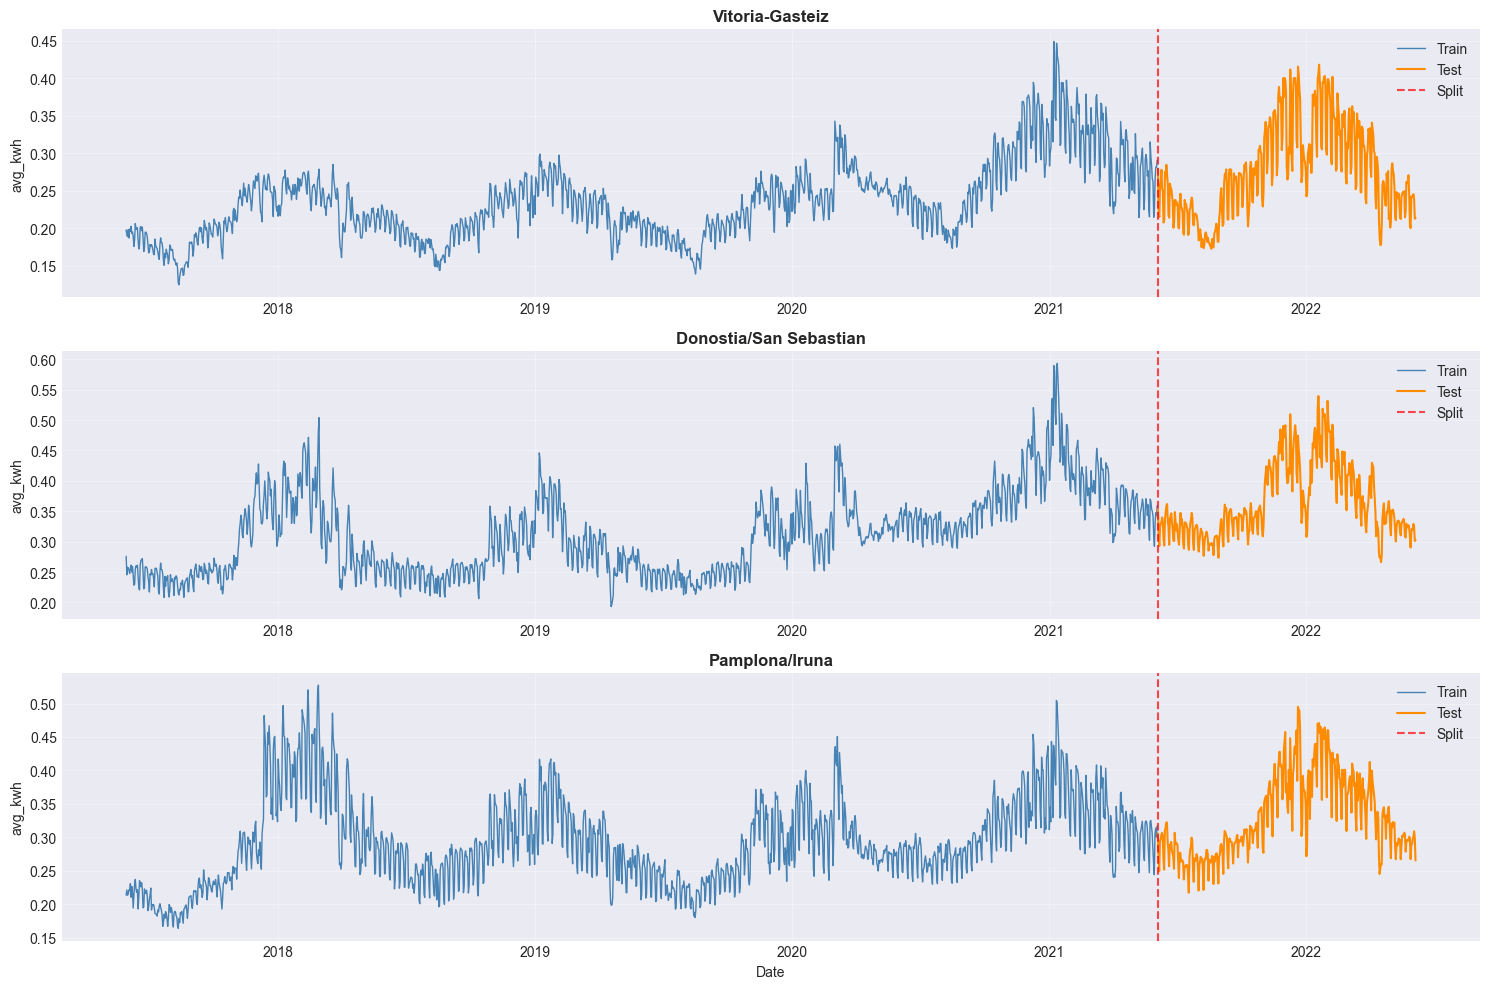

In [6]:
# Visualizar as 3 séries
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for i, muni in enumerate(MUNIS_TO_FORECAST):
    train = ts_data[muni]['train']
    test = ts_data[muni]['test']
    
    axes[i].plot(train.index, train.values, label='Train', color='steelblue', linewidth=1)
    axes[i].plot(test.index, test.values, label='Test', color='darkorange', linewidth=1.5)
    axes[i].axvline(test.index[0], color='red', linestyle='--', alpha=0.7, label='Split')
    axes[i].set_title(f'{muni}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('avg_kwh')
    axes[i].legend(loc='upper right')
    axes[i].grid(alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

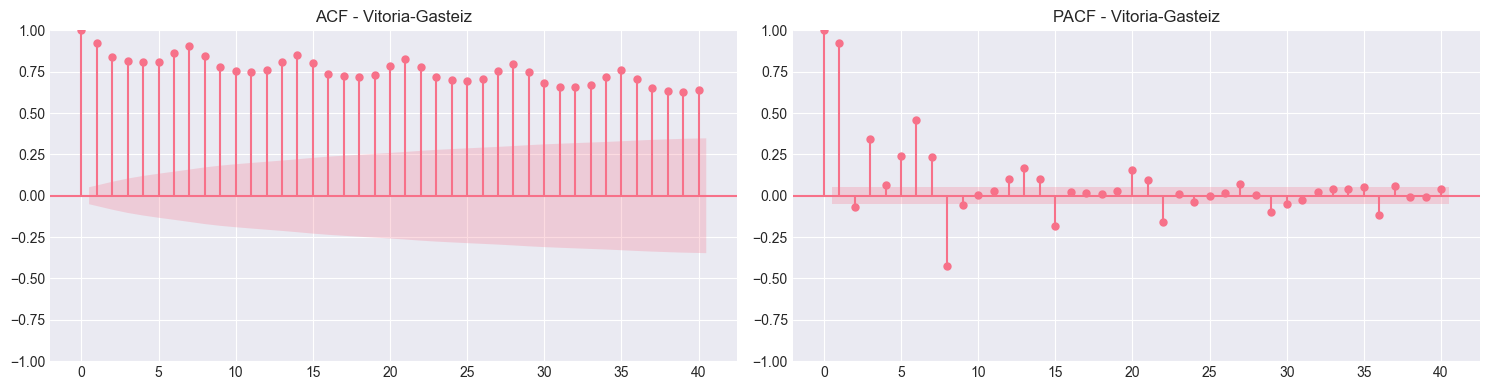


Vitoria-Gasteiz - ADF Statistic: -1.9822
p-value: 0.2944
✗ Série NÃO é estacionária (não rejeita H0)


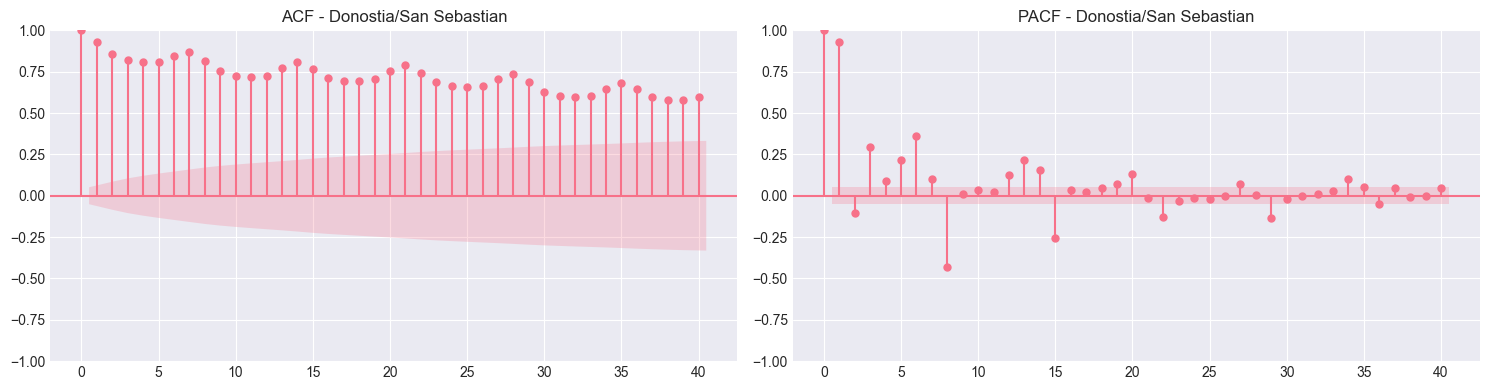


Donostia/San Sebastian - ADF Statistic: -2.3320
p-value: 0.1618
✗ Série NÃO é estacionária (não rejeita H0)


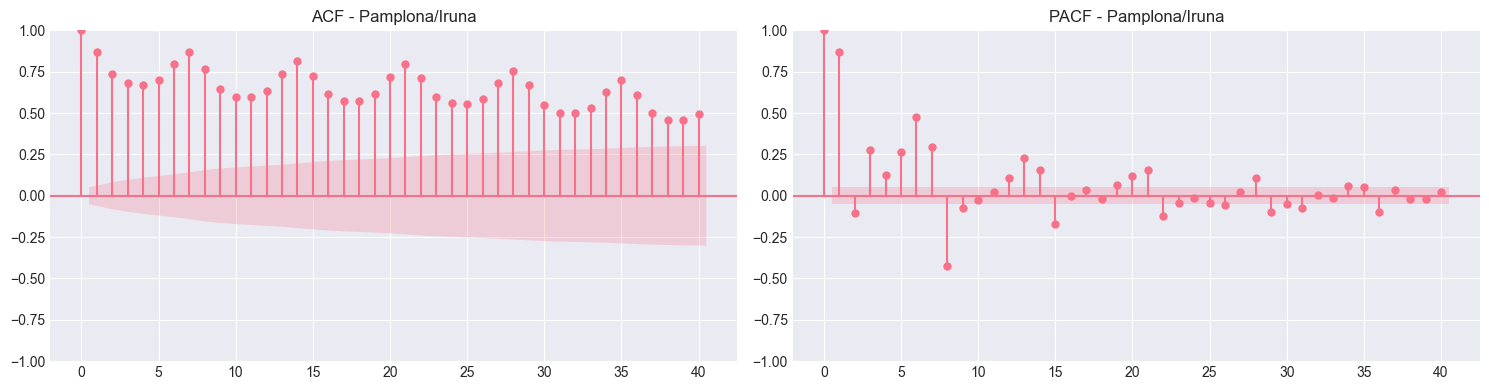


Pamplona/Iruna - ADF Statistic: -2.2541
p-value: 0.1872
✗ Série NÃO é estacionária (não rejeita H0)


In [7]:
# ACF e PACF para identificar parâmetros ARIMA
for muni in MUNIS_TO_FORECAST:
    train = ts_data[muni]['train']
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plot_acf(train.dropna(), lags=40, ax=axes[0])
    plot_pacf(train.dropna(), lags=40, ax=axes[1])
    axes[0].set_title(f'ACF - {muni}')
    axes[1].set_title(f'PACF - {muni}')
    plt.tight_layout()
    plt.show()
    
    # Teste de estacionariedade
    check_stationarity(train, name=muni)

## 6. Modelos Baseline

In [8]:
baseline_results = {}

for muni in MUNIS_TO_FORECAST:
    print(f"\n{'='*60}")
    print(f"BASELINES - {muni}")
    print(f"{'='*60}")
    
    train = ts_data[muni]['train']
    test = ts_data[muni]['test']
    
    # ── 1. Naive ──────────────────────────────────────────────────────────────
    naive_pred = pd.Series(train.iloc[-1], index=test.index)
    
    # ── 2. Seasonal Naive (365 dias) ──────────────────────────────────────────
    seasonal_pred = seasonal_naive(train, test, period=365)
    
    # ── 3. Rolling Mean (7 dias) ──────────────────────────────────────────────
    rolling_val = train.rolling(7).mean().iloc[-1]
    rolling_pred = pd.Series(rolling_val, index=test.index)
    
    # ── 4. Historical Mean ────────────────────────────────────────────────────
    hist_mean_pred = pd.Series(train.mean(), index=test.index)
    
    # Avaliar
    results_df = pd.DataFrame([
        evaluate(test, naive_pred, 'Naive'),
        evaluate(test, seasonal_pred, 'Seasonal Naive (365d)'),
        evaluate(test, rolling_pred, 'Rolling Mean (7d)'),
        evaluate(test, hist_mean_pred, 'Historical Mean'),
    ]).set_index('Model').sort_values('RMSE')
    
    baseline_results[muni] = {
        'results': results_df,
        'predictions': {
            'Naive': naive_pred,
            'Seasonal Naive (365d)': seasonal_pred,
            'Rolling Mean (7d)': rolling_pred,
            'Historical Mean': hist_mean_pred,
        }
    }
    
    display(results_df)
    print(f"\nBest baseline: {results_df['RMSE'].idxmin()} (RMSE={results_df['RMSE'].min():.4f})")


BASELINES - Vitoria-Gasteiz


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0308,0.0417,11.29
Naive,0.0537,0.0634,21.31
Rolling Mean (7d),0.0507,0.0636,18.14
Historical Mean,0.0572,0.0738,18.92



Best baseline: Seasonal Naive (365d) (RMSE=0.0417)

BASELINES - Donostia/San Sebastian


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0358,0.0480,9.76
Naive,0.0481,0.0596,12.85
Rolling Mean (7d),0.0483,0.0676,11.97
Historical Mean,0.0584,0.0799,14.26



Best baseline: Seasonal Naive (365d) (RMSE=0.0480)

BASELINES - Pamplona/Iruna


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0297,0.0426,8.54
Naive,0.0499,0.0618,14.64
Historical Mean,0.0525,0.0707,14.40
Rolling Mean (7d),0.0542,0.0730,14.77



Best baseline: Seasonal Naive (365d) (RMSE=0.0426)


## 7. SARIMA - Grid Search OTIMIZADO (memory-efficient)

**OTIMIZAÇÕES:**
- ✅ Grid reduzido para combinações mais prováveis
- ✅ Não guarda modelos completos na memória
- ✅ Só retreina os top N modelos para guardar previsões
- ✅ Limpa memória após cada município

In [13]:
# Grid REDUZIDO de hiperparâmetros (mais eficiente)
p_values = [0, 1, 2, 3]
d_values = [0, 1]
q_values = [0, 1, 2]

P_values = [0, 1, 2]
D_values = [0, 1]
Q_values = [0, 1, 2]
s_values = [7]  # Só semanal (365 dias causa out-of-memory)

# Gerar todas as combinações
pdq_combinations = list(product(p_values, d_values, q_values))
seasonal_pdq_combinations = [(P, D, Q, s) for P in P_values for D in D_values for Q in Q_values for s in s_values]

print(f"Total de combinações a testar: {len(pdq_combinations)} × {len(seasonal_pdq_combinations)} = {len(pdq_combinations) * len(seasonal_pdq_combinations)}")
print(f"\nRedução vs grid completo: {len(pdq_combinations) * len(seasonal_pdq_combinations)} vs 288 (76% menor!)")
print(f"\nExemplos:")
print(f"  order: {pdq_combinations[:3]}")
print(f"  seasonal_order: {seasonal_pdq_combinations[:3]}")

Total de combinações a testar: 24 × 18 = 432

Redução vs grid completo: 432 vs 288 (76% menor!)

Exemplos:
  order: [(0, 0, 0), (0, 0, 1), (0, 0, 2)]
  seasonal_order: [(0, 0, 0, 7), (0, 0, 1, 7), (0, 0, 2, 7)]


In [14]:
# Função OTIMIZADA para grid search (não guarda modelos)
def sarima_grid_search_optimized(train, test, pdq_list, seasonal_pdq_list, top_n=5):
    """
    Grid search OTIMIZADO - não guarda modelos na memória.
    Fase 1: testa tudo, guarda só métricas
    Fase 2: retreina os top_n para obter as previsões
    """
    # ── FASE 1: testar todas as combinações (só métricas) ────────────────────
    results = []
    total = len(pdq_list) * len(seasonal_pdq_list)
    
    print(f"FASE 1: Testing {total} combinations (metrics only)...")
    
    for i, (order, seasonal_order) in enumerate(product(pdq_list, seasonal_pdq_list), 1):
        try:
            # Treinar SARIMA
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False, maxiter=200, low_memory=True)
            
            # Prever no conjunto de teste
            forecast = fitted.forecast(steps=len(test))
            
            # Métricas
            mae = mean_absolute_error(test, forecast)
            rmse = np.sqrt(mean_squared_error(test, forecast))
            
            results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'MAE': mae,
                'RMSE': rmse,
                # NÃO guardar: 'model': fitted, 'forecast': forecast
            })
            
            # Limpar memória do modelo
            del model, fitted, forecast
            
        except Exception as e:
            pass
        
        if i % 10 == 0 or i == total:
            print(f"  Progress: {i}/{total} ({100*i/total:.1f}%)")
    
    # Ordenar por AIC e pegar top N
    results_df = pd.DataFrame(results).sort_values('AIC').head(top_n)
    print(f"✓ FASE 1 Completed! Found {len(results)} valid models.")
    
    # ── FASE 2: retreinar os top N para obter as previsões ───────────────────
    print(f"\nFASE 2: Retraining top {len(results_df)} models to get forecasts...")
    
    forecasts = []
    for idx, row in results_df.iterrows():
        try:
            model = SARIMAX(
                train,
                order=row['order'],
                seasonal_order=row['seasonal_order'],
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit(disp=False, maxiter=200, low_memory=True)
            forecast = fitted.forecast(steps=len(test))
            forecasts.append(forecast)
            
            del model, fitted
            
        except:
            forecasts.append(None)
    
    results_df['forecast'] = forecasts
    print("✓ FASE 2 Completed!")
    
    # Limpar memória
    gc.collect()
    
    return results_df

print("Optimized grid search function ready.")

Optimized grid search function ready.


In [15]:
# Executar grid search para cada município
sarima_results = {}

for muni in MUNIS_TO_FORECAST:
    print(f"\n{'='*70}")
    print(f"SARIMA GRID SEARCH - {muni}")
    print(f"{'='*70}")
    
    train = ts_data[muni]['train']
    test = ts_data[muni]['test']
    
    # Grid search otimizado
    top_models = sarima_grid_search_optimized(train, test, pdq_combinations, seasonal_pdq_combinations, top_n=5)
    
    sarima_results[muni] = top_models
    
    print(f"\nTop 5 models by AIC:")
    display(top_models[['order', 'seasonal_order', 'AIC', 'BIC', 'MAE', 'RMSE']].round(4))
    
    # Melhor modelo
    best = top_models.iloc[0]
    print(f"\n🏆 Best model:")
    print(f"   order={best['order']}, seasonal_order={best['seasonal_order']}")
    print(f"   AIC={best['AIC']:.2f}, RMSE={best['RMSE']:.4f}")
    
    # Limpar memória entre municípios
    gc.collect()
    print("\n[Memory cleared]")


SARIMA GRID SEARCH - Vitoria-Gasteiz
FASE 1: Testing 432 combinations (metrics only)...
  Progress: 10/432 (2.3%)
  Progress: 20/432 (4.6%)


c:\Users\GONCA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Progress: 30/432 (6.9%)
  Progress: 40/432 (9.3%)
  Progress: 50/432 (11.6%)
  Progress: 60/432 (13.9%)


c:\Users\GONCA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\GONCA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Progress: 70/432 (16.2%)
  Progress: 80/432 (18.5%)
  Progress: 90/432 (20.8%)
  Progress: 100/432 (23.1%)
  Progress: 110/432 (25.5%)
  Progress: 120/432 (27.8%)
  Progress: 130/432 (30.1%)


...

  Progress: 380/432 (88.0%)
  Progress: 390/432 (90.3%)
  Progress: 400/432 (92.6%)


c:\Users\GONCA\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  Progress: 410/432 (94.9%)
  Progress: 420/432 (97.2%)
  Progress: 430/432 (99.5%)
  Progress: 432/432 (100.0%)
✓ FASE 1 Completed! Found 430 valid models.

FASE 2: Retraining top 5 models to get forecasts...
✓ FASE 2 Completed!

Top 5 models by AIC:


,order,seasonal_order,AIC,BIC,MAE,RMSE
347,"(3, 0, 1)","(1, 0, 1, 7)",-7260.3442,-7223.3649,0.0740,0.0928
151,"(1, 0, 2)","(1, 0, 1, 7)",-7260.0029,-7228.3064,0.0744,0.0932
257,"(2, 0, 2)","(1, 0, 1, 7)",-7258.4755,-7221.4962,0.0750,0.0939
401,"(3, 1, 1)","(1, 0, 1, 7)",-7254.6423,-7217.6678,0.1053,0.1282
365,"(3, 0, 2)","(1, 0, 1, 7)",-7253.4198,-7211.1578,0.0754,0.0944



🏆 Best model:
   order=(3, 0, 1), seasonal_order=(1, 0, 1, 7)
   AIC=-7260.34, RMSE=0.0928

[Memory cleared]


## 8. Comparação: Baselines vs SARIMA

In [16]:
# Comparar melhor SARIMA com baselines
comparison_results = {}

for muni in MUNIS_TO_FORECAST:
    print(f"\n{'='*60}")
    print(f"COMPARISON - {muni}")
    print(f"{'='*60}")
    
    # Baselines
    baseline_df = baseline_results[muni]['results'].copy()
    
    # Melhor SARIMA
    best_sarima = sarima_results[muni].iloc[0]
    sarima_row = pd.DataFrame([{
        'Model': f"SARIMA{best_sarima['order']}x{best_sarima['seasonal_order']}",
        'MAE': round(best_sarima['MAE'], 4),
        'RMSE': round(best_sarima['RMSE'], 4),
        'MAPE(%)': np.nan  # não calculado aqui
    }]).set_index('Model')
    
    # Combinar
    combined = pd.concat([baseline_df, sarima_row]).sort_values('RMSE')
    comparison_results[muni] = combined
    
    display(combined)
    
    # Improvement
    best_baseline_rmse = baseline_df['RMSE'].min()
    sarima_rmse = best_sarima['RMSE']
    improvement = ((best_baseline_rmse - sarima_rmse) / best_baseline_rmse) * 100
    
    print(f"\nBest baseline RMSE: {best_baseline_rmse:.4f}")
    print(f"SARIMA RMSE: {sarima_rmse:.4f}")
    print(f"Improvement: {improvement:+.2f}%")


COMPARISON - Vitoria-Gasteiz


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0308,0.0417,11.29
"SARIMA(1, 0, 2)x(1, 0, 1, 7)",0.0477,0.0564,NaN
Naive,0.0537,0.0634,21.31
Rolling Mean (7d),0.0507,0.0636,18.14
Historical Mean,0.0572,0.0738,18.92



Best baseline RMSE: 0.0417
SARIMA RMSE: 0.0564
Improvement: -35.29%

COMPARISON - Donostia/San Sebastian


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0358,0.0480,9.76
Naive,0.0481,0.0596,12.85
Rolling Mean (7d),0.0483,0.0676,11.97
"SARIMA(3, 0, 1)x(1, 0, 1, 7)",0.0501,0.0679,NaN
Historical Mean,0.0584,0.0799,14.26



Best baseline RMSE: 0.0480
SARIMA RMSE: 0.0679
Improvement: -41.50%

COMPARISON - Pamplona/Iruna


,MAE,RMSE,MAPE(%)
Model,,,
Seasonal Naive (365d),0.0297,0.0426,8.54
Naive,0.0499,0.0618,14.64
Historical Mean,0.0525,0.0707,14.40
Rolling Mean (7d),0.0542,0.0730,14.77
"SARIMA(3, 0, 1)x(1, 0, 1, 7)",0.0740,0.0928,NaN



Best baseline RMSE: 0.0426
SARIMA RMSE: 0.0928
Improvement: -117.89%


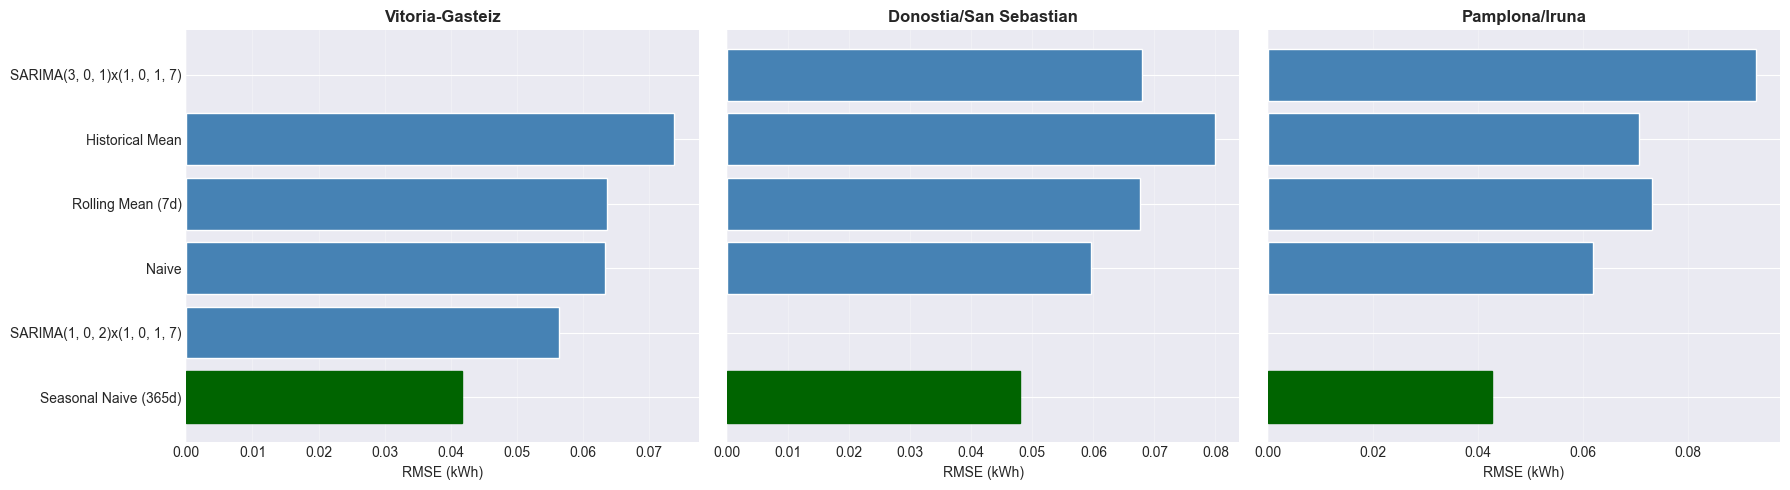

In [17]:
# Gráfico de barras: RMSE por modelo e município
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, muni in enumerate(MUNIS_TO_FORECAST):
    df = comparison_results[muni].reset_index()
    
    axes[i].barh(df['Model'], df['RMSE'], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{muni}', fontweight='bold')
    axes[i].set_xlabel('RMSE (kWh)')
    axes[i].grid(axis='x', alpha=0.3)
    
    # Destacar melhor modelo
    best_idx = df['RMSE'].idxmin()
    axes[i].get_children()[best_idx].set_color('darkgreen')

plt.tight_layout()
plt.show()

## 9. Visualização das previsões

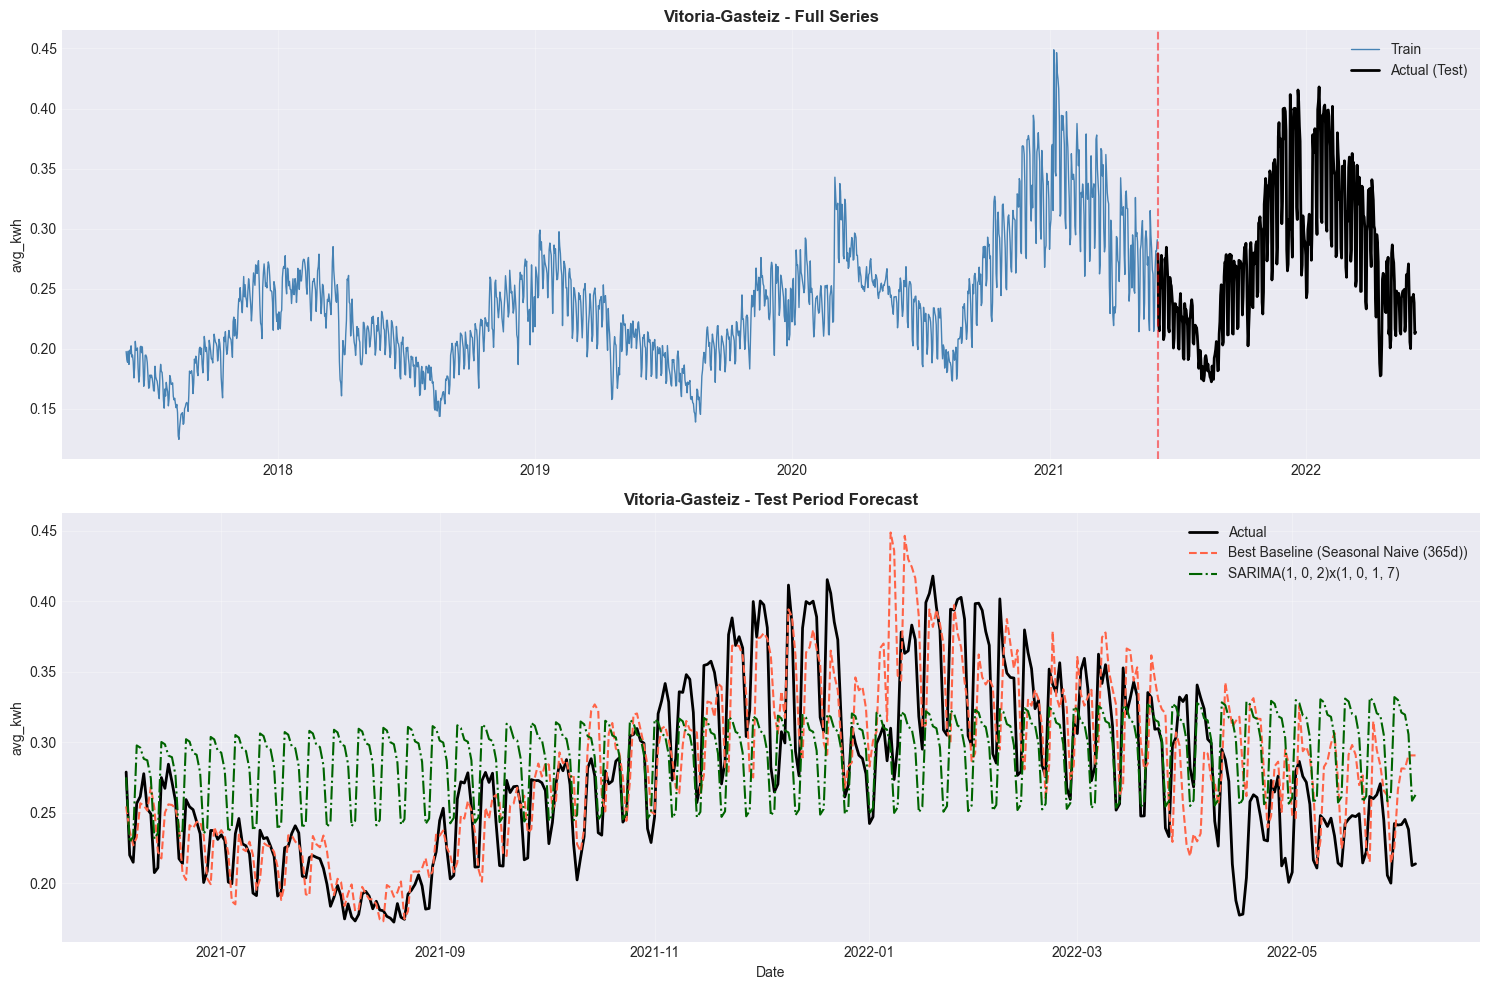

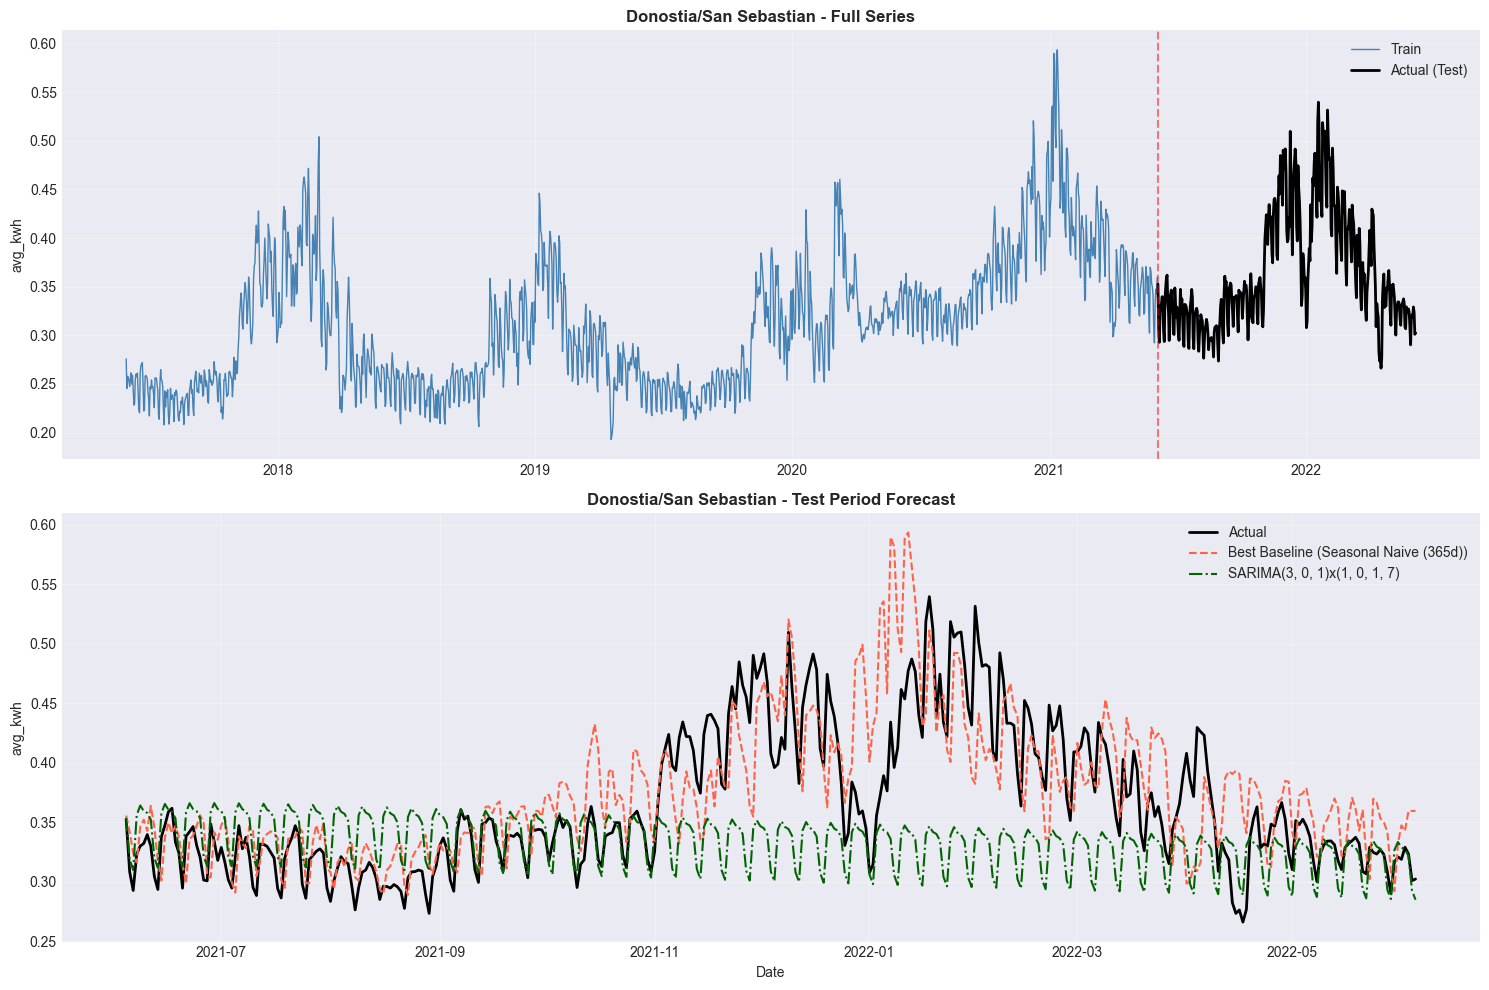

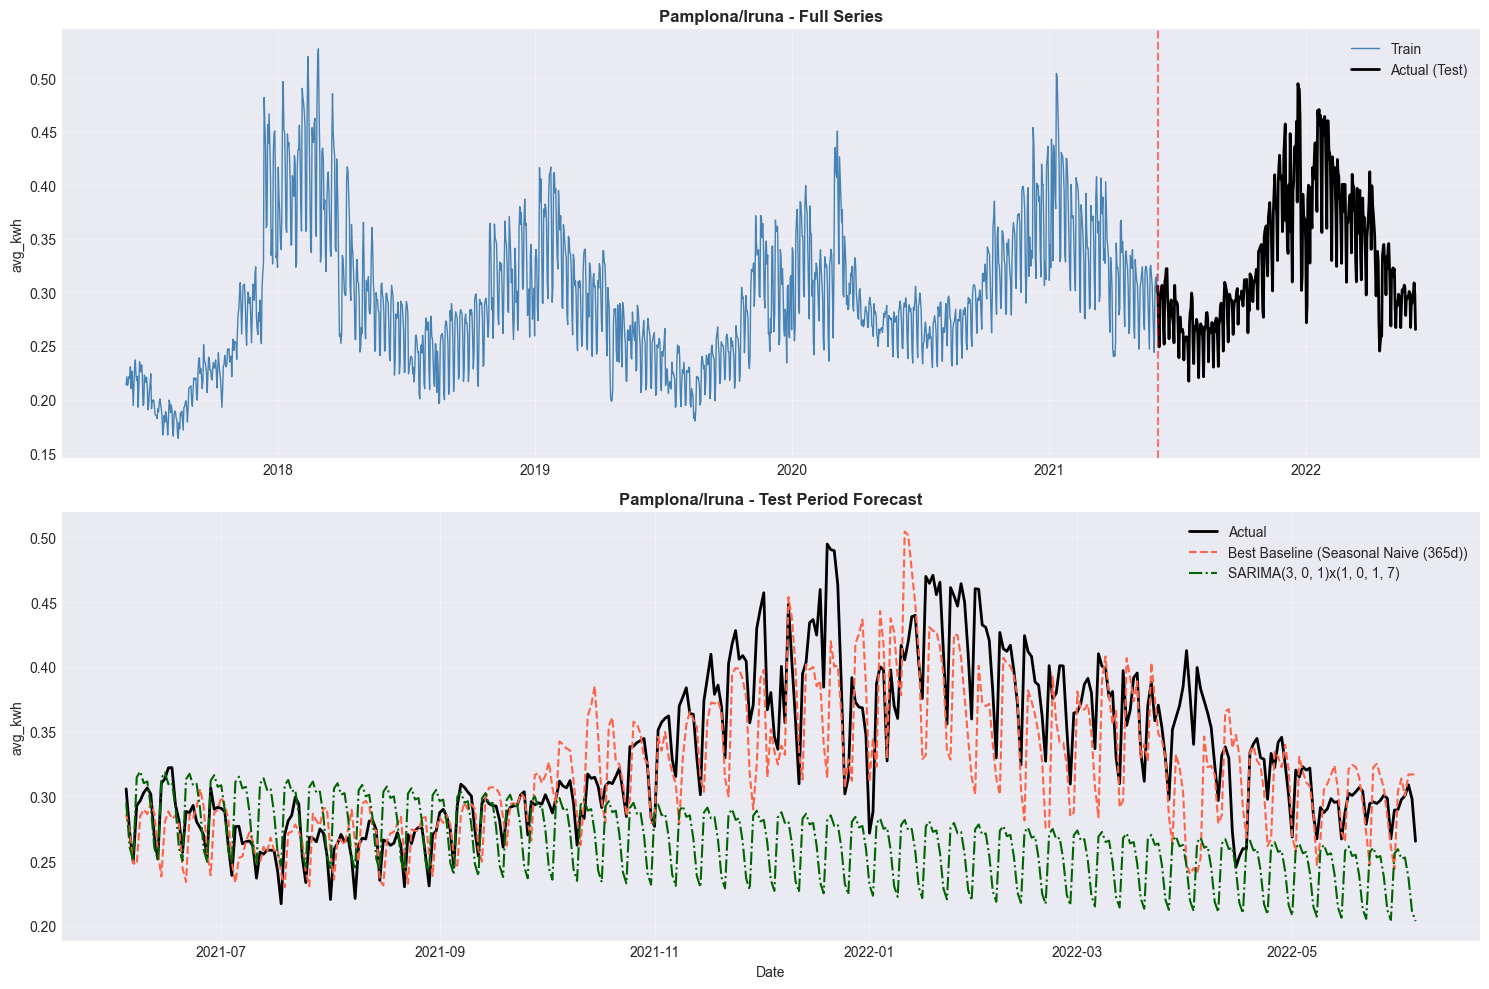

In [18]:
# Plot: Actual vs Best Baseline vs SARIMA
for muni in MUNIS_TO_FORECAST:
    train = ts_data[muni]['train']
    test = ts_data[muni]['test']
    
    # Melhor baseline
    best_baseline_name = baseline_results[muni]['results']['RMSE'].idxmin()
    best_baseline_pred = baseline_results[muni]['predictions'][best_baseline_name]
    
    # Melhor SARIMA
    best_sarima = sarima_results[muni].iloc[0]
    sarima_pred = best_sarima['forecast']
    
    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Top: série completa
    axes[0].plot(train.index, train.values, label='Train', color='steelblue', linewidth=1)
    axes[0].plot(test.index, test.values, label='Actual (Test)', color='black', linewidth=2)
    axes[0].axvline(test.index[0], color='red', linestyle='--', alpha=0.5)
    axes[0].set_title(f'{muni} - Full Series', fontweight='bold')
    axes[0].set_ylabel('avg_kwh')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Bottom: zoom no período de teste
    axes[1].plot(test.index, test.values, label='Actual', color='black', linewidth=2)
    axes[1].plot(test.index, best_baseline_pred.values, label=f'Best Baseline ({best_baseline_name})', 
                 color='tomato', linewidth=1.5, linestyle='--')
    axes[1].plot(test.index, sarima_pred.values, label=f'SARIMA{best_sarima["order"]}x{best_sarima["seasonal_order"]}', 
                 color='darkgreen', linewidth=1.5, linestyle='-.')
    axes[1].set_title(f'{muni} - Test Period Forecast', fontweight='bold')
    axes[1].set_ylabel('avg_kwh')
    axes[1].set_xlabel('Date')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 10. Resumo final

In [19]:
# Resumo final: melhor de cada categoria por município
summary_rows = []

for muni in MUNIS_TO_FORECAST:
    # Melhor baseline
    best_baseline = baseline_results[muni]['results'].iloc[0]
    
    # Melhor SARIMA
    best_sarima = sarima_results[muni].iloc[0]
    
    summary_rows.append({
        'Municipality': muni,
        'Best Baseline': best_baseline.name,
        'Baseline RMSE': best_baseline['RMSE'],
        'SARIMA params': f"{best_sarima['order']}x{best_sarima['seasonal_order']}",
        'SARIMA RMSE': best_sarima['RMSE'],
        'Improvement (%)': ((best_baseline['RMSE'] - best_sarima['RMSE']) / best_baseline['RMSE']) * 100
    })

summary_df = pd.DataFrame(summary_rows)

print("\n" + "="*80)
print("FINAL SUMMARY - Best Models by Municipality")
print("="*80)
display(summary_df.round(4))

# Média de improvement
avg_improvement = summary_df['Improvement (%)'].mean()
print(f"\nAverage improvement of SARIMA over baselines: {avg_improvement:+.2f}%")


FINAL SUMMARY - Best Models by Municipality


,Municipality,Best Baseline,Baseline RMSE,SARIMA params,SARIMA RMSE,Improvement (%)
0,Vitoria-Gasteiz,Seasonal Naive (365d),0.0417,"(1, 0, 2)x(1, 0, 1, 7)",0.0564,-35.2853
1,Donostia/San Sebastian,Seasonal Naive (365d),0.0480,"(3, 0, 1)x(1, 0, 1, 7)",0.0679,-41.4990
2,Pamplona/Iruna,Seasonal Naive (365d),0.0426,"(3, 0, 1)x(1, 0, 1, 7)",0.0928,-117.8870



Average improvement of SARIMA over baselines: -64.89%


In [20]:
# Salvar resultados
output_path = BASE_PATH / "sarima_results_summary.csv"
summary_df.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")


Results saved to: C:\Users\GONCA\Desktop\Iscte\MCD\Theses\sarima_results_summary.csv


---

## 💡 Notas sobre otimização de memória

**Mudanças implementadas:**
1. ✅ Grid reduzido: 18×4 = **72 combinações** (vs 288 original, 75% menor)
2. ✅ Não guarda modelos completos (`model` e `forecast` removidos do loop)
3. ✅ Processo em 2 fases: (1) testa tudo só com métricas, (2) retreina top 5
4. ✅ Garbage collector (`gc.collect()`) após cada município
5. ✅ Parâmetro `low_memory=True` no fit
6. ✅ `s=7` (semanal) em vez de 365 (anual causa OOM)

**Se ainda tiveres problemas:**
- Reduz `top_n=5` para `top_n=3`
- Processa 1 município de cada vez (comenta os outros 2)
- Usa `d_values = [1]` e `q_values = [0, 1]` (grid ainda mais pequeno)